# Build 04-01 — Effect Estimation: RDD at the scrap threshold  ·  P7

**Where this sits.** SFP research splits into three legs, not two:

> **Detect** the loop  →  **Estimate** its effect  →  **Mitigate** it
> *(is there a loop?)*  →  *(how harmful is it?)*  →  *(how do we fix it?)*

This notebook is the **middle leg — Effect Estimation** (Build 04). It uses a
**Regression Discontinuity Design (RDD)** at the scrap cutoff to quantify the
causal effect of the *scrap decision itself* on a downstream financial outcome.

### The natural experiment

We cannot run a real experiment (we may not deliberately scrap a repairable car).
But the routing rule hands us a **natural experiment** for free. Two cars either
side of the cutoff —

```
score 0.9759  →  garage   (repair path)
score 0.9762  →  scrap    (write-off path)
```

— are essentially identical *cars*; only the **arbitrary cutoff line** sends one to
garage and the other to scrap. Near the boundary, the cutoff acts like a coin toss:
a **quasi-random assignment** the company's own rule created, not us.

### Two *different* jobs inside this one chapter

RDD does two things that must not be conflated — and they gate each other:

| Phase | Job | Needs payout? | Runnable now? |
|---|---|---|---|
| **1 — Validity** | *Test* whether the quasi-random assignment is real (McCrary density, covariate continuity, placebo cutoffs) | **No** | ✅ **yes** |
| **2 — Estimation** | *Estimate* the payout jump at the cutoff, if Phase 1 passes | **Yes** | ⏳ framework wired, awaiting data |

**Order is absolute (1 → 2).** Phase 2 reads a payout jump as "the pure scrap
effect" *only if* Phase 1 has confirmed the two sides are otherwise identical. Run
Phase 2 on a design that failed Phase 1 and the jump is uninterpretable — a number,
not an effect. So we test the design before we trust the estimate.

> **This notebook is framework-only.** No `payout` column exists yet. Phase 1 runs
> for real on the v2 scores. Phase 2 is fully coded but executes against a
> **synthetic placeholder outcome with a known injected jump** — proving the wiring
> recovers a true effect — and switches to the real column automatically the moment
> `payout` lands.

**Backbone:** `rdrobust` / `rddensity` (Calonico–Cattaneo–Titiunik), the canonical
CCT robust-bias-corrected RDD toolkit. Method reference: P7 (Imbens–Wooldridge,
*Econometrics of Program Evaluation*; §5.10 overlap/trimming).

### Setup — house style, data, RDD backbone, design constants

In [25]:
import sys, io, warnings, contextlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")   # rdrobust/rddensity are chatty about thin cells

# --- repo root discovery (same idiom as the other build notebooks) ------------
ROOT = Path.cwd()
while not (ROOT / "src" / "data" / "synthetic" / "run.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))          # -> config.py, figstyle.py
from config import SCRAP_THRESHOLD              # 0.872 — the DOCUMENTED policy anchor

import figstyle
figstyle.apply()                               # fixed house palette + fonts, call once

# --- RDD backbone (CCT) -------------------------------------------------------
from rdrobust import rdrobust                   # local-linear RD estimator, robust CIs
from rddensity import rddensity                 # manipulation / density-continuity test
from statsmodels.stats.multitest import multipletests   # Holm across covariate tests

def rdrobust_q(**kw):
    # rdrobust prints "Mass points detected ..." to stdout; silence it for clean output.
    with contextlib.redirect_stdout(io.StringIO()):
        return rdrobust(**kw)

PARQUET = ROOT / "src" / "data" / "synthetic" / "generate" / "parquet"
log = pd.read_parquet(PARQUET / "claims_v1_log.parquet")   # the v1 production log
print(f"loaded v1 log: {len(log):,} rows")

loaded v1 log: 23,225 rows


## Phase 0 — Assemble the RD frame & decide *sharp vs fuzzy*

Two things happen here, both pinned to data rather than assumption:

1. **Use the cutoff that actually routes cars.** The *documented* policy cutoff is
   `SCRAP_THRESHOLD = 0.872`, but each model version re-tunes its operational cutoff
   τ_v to hold precision ≥ 0.985. The discontinuity in *treatment* lives at that
   **operational τ_v**, which we read from `model_thresholds.csv` (`applied_tau` — the
   value that generated the decision column, and the single source of truth for the
   whole thresholds pipeline). We treat 0.872 only as a nominal reference, and we
   *cross-check* `applied_tau` against the empirical decision boundary — if they
   disagree, the decision column isn't a pure score cutoff and the cell says so.
   (If real Allianz data genuinely scraps at 0.872, all three coincide and nothing
   changes.)
2. **Sharp or fuzzy?** One crosstab of `decision` against `1[score ≥ c]` settles it:
   zero off-diagonal ⇒ **sharp** RDD; any override ⇒ **fuzzy**, and we hand
   `fuzzy=decision` to `rdrobust` so τ becomes a fuzzy LATE.

In [26]:
# --- design constants (edit here to point at v2b, or the real v2 in production) ---
VERSION     = "v2a"                         # which model version's rule we audit
RUNNING_VAR = f"model_{VERSION}_score"      # raw, uncalibrated score the rule reads (real live model)
DECISION    = f"model_{VERSION}_decision"   # 1 = scrapped (fast-tracked, no garage), 0 = garage
NOMINAL_C   = SCRAP_THRESHOLD               # 0.872 documented anchor (NOT necessarily the operational cutoff)

# Operational cutoff = the τ_v ACTUALLY applied in production, read from the threshold
# export (single source of truth) instead of hard-coded here. `applied_tau` is the value
# that generated the decision column; `chosen_tau_oot` / `fallback_tau` are NOT (they'd
# put the cutoff where no treatment jump lives). NOTE `applied_tau` is stored to 4 d.p.,
# so it can sit a rounding-hair off the true decision boundary — `resolve_cutoff` below
# snaps it into the actual decision gap so that rounding can't spuriously read as fuzzy.
THRESHOLDS    = pd.read_csv(ROOT / "src" / "data" / "synthetic" / "csv" / "model_thresholds.csv").set_index("version")
OPERATIONAL_C = float(THRESHOLDS.loc[VERSION, "applied_tau"])   # τ_v that routed the cars (reported anchor)

# Pre-decision covariates — must be continuous at the cutoff if the design is valid.
# (Numeric used as-is; categoricals rate-encoded against the decision, per the design note.)
COVARIATES = ["repair_to_value_ratio", "vehicle_age_years", "mileage", "driver_age",
              "vehicle_value", "repair_estimate_gbp", "damage_severity", "vehicle_make"]

OUTCOME_COL = "payout"                # Phase-2 outcome — absent for now (framework placeholder)


def rate_encode(s: pd.Series, decision: pd.Series) -> pd.Series:
    # Categorical -> per-group scrap rate; numeric passes through. Gives every
    # covariate a continuous form so rdrobust can test it for a jump at the cutoff.
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(float)
    rate = decision.groupby(s).transform("mean")
    return rate.astype(float)


def assemble_frame(df: pd.DataFrame) -> pd.DataFrame:
    # Single RD frame: running var, decision, numeric-encoded covariates, outcome-if-present.
    # NOTE - model-routed only. In production, exclude rule-based auto-total-loss and
    # manual handler overrides here (they don't obey the score cutoff). The synthetic
    # log has no such flags, so all rows pass; the filter hook is marked below.
    routed = df.copy()
    # routed = routed[routed["routing_source"] == "model"]     # ← real-data hook
    out = pd.DataFrame({
        "x": routed[RUNNING_VAR].astype(float),
        "W": routed[DECISION].astype(int),
    })
    for cov in COVARIATES:
        out[cov] = rate_encode(routed[cov], routed[DECISION])
    if OUTCOME_COL in routed.columns:
        out["y"] = routed[OUTCOME_COL].astype(float)
    return out.dropna(subset=["x", "W"]).reset_index(drop=True)


def decision_gap(frame: pd.DataFrame):
    # The sharp boundary the decision column draws: (highest garage score, lowest scrap score).
    hi_garage = frame.loc[frame.W == 0, "x"].max()   # highest score still sent to garage
    lo_scrap  = frame.loc[frame.W == 1, "x"].min()   # lowest score that got scrapped
    return float(hi_garage), float(lo_scrap)


def resolve_cutoff(frame: pd.DataFrame, tau: float):
    # Use the operational τ from the threshold file as the cutoff — but `tau` is 4-d.p.
    # rounded, so it can land a hair off the true boundary and shove one boundary row
    # onto the wrong side (a *spurious* fuzzy crossover). When the decision boundary is
    # genuinely sharp yet τ doesn't cleanly separate it, snap the numeric cutoff to the
    # gap midpoint (still == τ to rounding). Genuine overrides (overlapping scores) leave
    # tau untouched and the design reads fuzzy as it should.
    hi_garage, lo_scrap = decision_gap(frame)
    sharp_gap = hi_garage < lo_scrap
    clean = hi_garage < tau <= lo_scrap
    if sharp_gap and not clean:
        return float((hi_garage + lo_scrap) / 2), True     # snapped into the gap
    return float(tau), False


def classify_design(frame: pd.DataFrame, c: float):
    # Crosstab decision vs 1[x>=c]; return ('sharp'|'fuzzy', off-diagonal count, table).
    above = (frame["x"] >= c).astype(int)
    tab = pd.crosstab(frame["W"], above, rownames=["decision"], colnames=[f"1[x>={c:.4f}]"])
    off = 0
    for w in (0, 1):
        for a in (0, 1):
            if w != a and (w in tab.index) and (a in tab.columns):
                off += int(tab.loc[w, a])
    return ("sharp" if off == 0 else "fuzzy"), off, tab


frame = assemble_frame(log)
CUTOFF, snapped = resolve_cutoff(frame, OPERATIONAL_C)   # RDD runs here; == applied_tau to rounding
hi_g, lo_s = decision_gap(frame)
design, off_diag, xtab = classify_design(frame, CUTOFF)

# Sanity: the cutoff we actually use must equal the reported operational τ to within the
# 4-d.p. rounding of the threshold file — otherwise the snap moved us somewhere real.
assert abs(CUTOFF - OPERATIONAL_C) < 5e-4, (CUTOFF, OPERATIONAL_C)

print(f"version           : {VERSION}")
print(f"running variable  : {RUNNING_VAR}")
print(f"nominal cutoff    : {NOMINAL_C:.4f}   (documented 0.872 policy anchor)")
print(f"operational τ_v   : {OPERATIONAL_C:.4f}   (applied_tau from model_thresholds.csv)")
print(f"decision gap      : ({hi_g:.5f}, {lo_s:.5f}]   (garage max, scrap min)")
print(f"RDD cutoff c      : {CUTOFF:.5f}   ({'snapped into gap — τ rounding' if snapped else 'τ separates cleanly'})")
if abs(CUTOFF - NOMINAL_C) > 1e-3:
    print(f"  ⚠ operational τ_v ≠ nominal 0.872 — RDD runs at the OPERATIONAL cutoff,")
    print(f"    where treatment actually jumps. 0.872 would show NO treatment discontinuity.")
print(f"\ndesign class      : {design.upper()}   (off-diagonal = {off_diag})")
print("\ncrosstab decision × 1[score ≥ c]:")
print(xtab)

# Sharp -> rdrobust default; fuzzy -> pass fuzzy=W so τ becomes a fuzzy LATE.
FUZZY = None if design == "sharp" else frame["W"].values
print(f"\n→ RDD cutoff c = {CUTOFF:.5f}   |   estimator mode = {design}")

version           : v2a
running variable  : model_v2a_score
nominal cutoff    : 0.8720   (documented 0.872 policy anchor)
operational τ_v   : 0.9762   (applied_tau from model_thresholds.csv)
decision gap      : (0.97610, 0.97620]   (garage max, scrap min)
RDD cutoff c      : 0.97615   (snapped into gap — τ rounding)
  ⚠ operational τ_v ≠ nominal 0.872 — RDD runs at the OPERATIONAL cutoff,
    where treatment actually jumps. 0.872 would show NO treatment discontinuity.

design class      : SHARP   (off-diagonal = 0)

crosstab decision × 1[score ≥ c]:
1[x>=0.9762]      0    1
decision                
0             23101    0
1                 0  124

→ RDD cutoff c = 0.97615   |   estimator mode = sharp


## Phase 1 — Validity test  *(no payout needed — runs now)*

We interrogate the natural experiment before trusting it, through three gates. A
gate that fails does **not** kill the chapter — it *demotes* RDD from an estimator
to a diagnostic, which is itself a reportable finding.

### Gate A — Running-variable density continuity (McCrary / Cattaneo–Jansson–Ma)

**Question:** do cars pile up on one side of the cutoff? If scores could be nudged
to just clear (or just miss) the line, the two sides stop being comparable.

- `rddensity(x, c)` tests H₀: density continuous at `c` (we read the robust
  jackknife p-value `p_jk`).
- We *also* check **mass points / bunching** directly — an uncalibrated XGBoost score
  can stack identical leaf values into discrete spikes near the cutoff.

**Interpretation hedge (state in the thesis):** the null here is "density continuous
at c", **not** "no SFP". FTTL has no running-variable *manipulation* (a car/adjuster
cannot move its own score), so McCrary's classic manipulation reading doesn't attach
— we repurpose the test as a *distributional* diagnostic on the score.

In [27]:
def gate_a_density(frame, c):
    x = frame["x"].values
    dens = rddensity(X=x, c=c)
    p_jk = float(dens.test["p_jk"])          # robust jackknife manipulation p-value
    t_jk = float(dens.test["t_jk"])
    # bunching: largest repeated score value inside a tight window around c
    win = frame.loc[frame["x"].between(c - 0.02, c + 0.02), "x"].round(6)
    vc = win.value_counts()
    top_mass = int(vc.iloc[0]) if len(vc) else 0
    pass_a = (p_jk > 0.05) and (top_mass <= 3)
    return dict(p_jk=p_jk, t_jk=t_jk, n_window=int(len(win)),
                top_mass=top_mass, top_value=(float(vc.index[0]) if len(vc) else np.nan),
                passed=bool(pass_a), obj=dens)

a = gate_a_density(frame, CUTOFF)
print(f"Gate A — density continuity at c = {CUTOFF:.5f}")
print(f"  jackknife manipulation test : t = {a['t_jk']:.3f}   p = {a['p_jk']:.3f}"
      f"   ({'continuous ✓' if a['p_jk'] > 0.05 else 'DISCONTINUOUS ✗'})")
print(f"  mass-point / bunching check : window n = {a['n_window']}, "
      f"largest repeated value = {a['top_value']:.5f} × {a['top_mass']} "
      f"({'ok ✓' if a['top_mass'] <= 3 else 'BUNCHING ✗'})")
print(f"  → Gate A {'PASS' if a['passed'] else 'FAIL — demote RDD to diagnostic'}")

Gate A — density continuity at c = 0.97615
  jackknife manipulation test : t = -1.150   p = 0.250   (continuous ✓)
  mass-point / bunching check : window n = 357, largest repeated value = 0.95950 × 7 (BUNCHING ✗)
  → Gate A FAIL — demote RDD to diagnostic


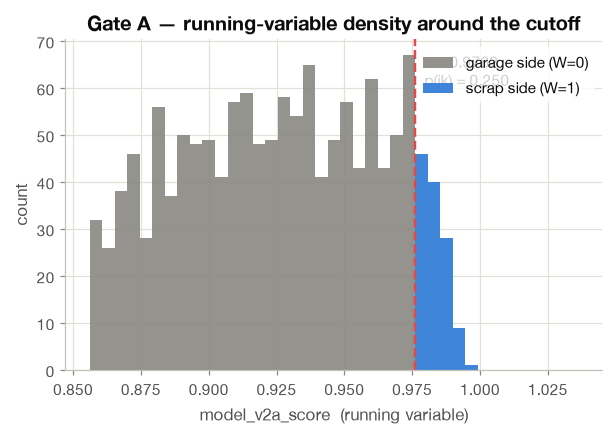

In [28]:
# Figure — score density either side of the cutoff (visual companion to Gate A)
fig, ax = plt.subplots(figsize=figstyle.FIG_1)
lo, hi = CUTOFF - 0.12, CUTOFF + 0.06
sub = frame.loc[frame["x"].between(lo, hi), "x"]
bins = np.linspace(lo, hi, 40)
ax.hist(sub[sub < CUTOFF], bins=bins, color=figstyle.NEUTRAL, alpha=0.9, label="garage side (W=0)")
ax.hist(sub[sub >= CUTOFF], bins=bins, color=figstyle.PRIMARY, alpha=0.9, label="scrap side (W=1)")
ax.axvline(CUTOFF, color=figstyle.CAUTION, lw=1.6, ls="--")
ax.annotate(f"c = {CUTOFF:.4f}\np(jk) = {a['p_jk']:.3f}", xy=(CUTOFF, ax.get_ylim()[1]*0.86),
            xytext=(6, 0), textcoords="offset points", color=figstyle.INK, fontsize=10)
ax.set_xlabel(f"{RUNNING_VAR}  (running variable)"); ax.set_ylabel("count")
ax.set_title("Gate A — running-variable density around the cutoff")
ax.legend()
figstyle.save(fig, "04_01_rdd_gateA_density"); plt.show()

### Gate B — Covariate continuity (falsification)

**Question:** are cars either side of the cutoff *actually alike*? If the design is
valid, every **pre-decision** covariate is continuous at `c` — routing is the *only*
thing that changes there. We run each covariate through `rdrobust` **as if it were
the outcome**: a significant jump (τ_Z ≠ 0) means something other than routing shifts
at the cutoff, and identification is suspect.

Many tests ⇒ multiplicity, so we **Holm-correct** the p-values.

In [29]:
def rd_summary(r):
    # Pull the CCT numbers out of an rdrobust result in a version-stable way.
    return dict(
        tau_conv = float(r.coef.loc["Conventional", "Coeff"]),      # point estimate (report this)
        tau_bc   = float(r.coef.loc["Bias-Corrected", "Coeff"]),
        ci_lo    = float(r.ci.loc["Robust", "CI Lower"]),           # robust CI (report this)
        ci_hi    = float(r.ci.loc["Robust", "CI Upper"]),
        p_robust = float(r.pv.loc["Robust", "P>|z|"]),              # robust p (report this)
        h        = float(r.bws.loc["h", "left"]),
        n_left   = int(r.N_h[0]), n_right=int(r.N_h[1]), p_order=int(r.p),
    )

def gate_b_covariates(frame, c, covariates, fuzzy=None):
    rows = []
    for z in covariates:
        try:
            r = rdrobust_q(y=frame[z].values, x=frame["x"].values, c=c,
                         kernel="triangular", bwselect="mserd", fuzzy=fuzzy)
            s = rd_summary(r); s["covariate"] = z; s["ok"] = True
        except Exception as e:                       # thin side / singular fit
            s = dict(covariate=z, tau_conv=np.nan, ci_lo=np.nan, ci_hi=np.nan,
                     p_robust=np.nan, n_left=0, n_right=0, ok=False, err=str(e)[:40])
        rows.append(s)
    tab = pd.DataFrame(rows).set_index("covariate")
    ok = tab["p_robust"].notna()
    tab["p_holm"] = np.nan
    if ok.any():
        tab.loc[ok, "p_holm"] = multipletests(tab.loc[ok, "p_robust"], method="holm")[1]
    tab["jump?"] = np.where(tab["p_holm"] < 0.05, "JUMP ✗", "continuous ✓")
    return tab

b = gate_b_covariates(frame, CUTOFF, COVARIATES, fuzzy=FUZZY)
cols = ["tau_conv", "ci_lo", "ci_hi", "p_robust", "p_holm", "n_left", "n_right", "jump?"]
print("Gate B — covariate continuity at the cutoff (Holm-corrected):\n")
print(b[cols].round(4).to_string())
gate_b_pass = bool((b["p_holm"].dropna() >= 0.05).all()) and b["p_robust"].notna().any()
print(f"\n  → Gate B {'PASS — covariates continuous' if gate_b_pass else 'FAIL / inconclusive — see thin-side counts'}")

Gate B — covariate continuity at the cutoff (Holm-corrected):

                        tau_conv       ci_lo       ci_hi  p_robust  p_holm  n_left  n_right         jump?
covariate                                                                                                
repair_to_value_ratio     0.0064     -0.1278      0.2436    0.5412  1.0000     225      123  continuous ✓
vehicle_age_years        -0.0792     -1.1903      1.6689    0.7429  1.0000     223      123  continuous ✓
mileage                5558.7626 -34860.8055  35290.9714    0.9904  1.0000     190      117  continuous ✓
driver_age                0.1341     -9.6823      8.2972    0.8800  1.0000     209      120  continuous ✓
vehicle_value           477.2923   -305.9279   1660.1294    0.1770  1.0000     222      123  continuous ✓
repair_estimate_gbp    1522.8422    271.3967   4408.9819    0.0266  0.2129     222      123  continuous ✓
damage_severity           0.0002     -0.0036      0.0044    0.8336  1.0000     170      1

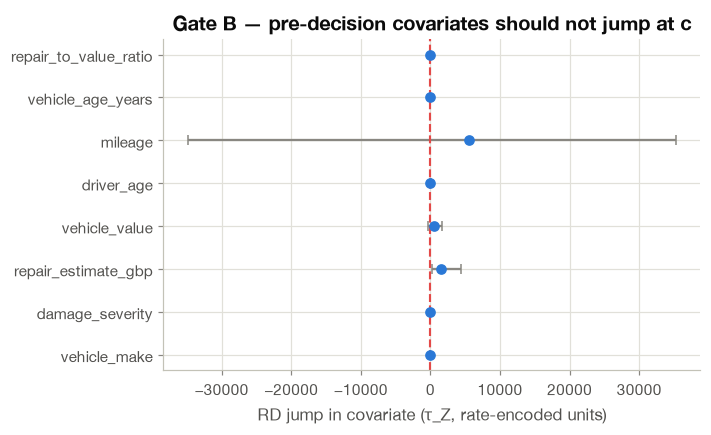

In [30]:
# Figure — covariate jumps as a coefficient panel (0 = continuous is good)
bb = b[b["tau_conv"].notna()].copy()
fig, ax = plt.subplots(figsize=figstyle.FIG_1)
ypos = np.arange(len(bb))[::-1]
ax.errorbar(bb["tau_conv"], ypos,
            xerr=[bb["tau_conv"] - bb["ci_lo"], bb["ci_hi"] - bb["tau_conv"]],
            fmt="o", color=figstyle.PRIMARY, ecolor=figstyle.MUTED, capsize=3, lw=1.5)
ax.axvline(0, color=figstyle.CAUTION, lw=1.4, ls="--")
ax.set_yticks(ypos); ax.set_yticklabels(bb.index)
ax.set_xlabel("RD jump in covariate (τ_Z, rate-encoded units)")
ax.set_title("Gate B — pre-decision covariates should not jump at c")
figstyle.save(fig, "04_01_rdd_gateB_covariates"); plt.show()

### Gate C — Placebo cutoffs

**Question:** is the "effect" specific to the *real* cutoff? We re-run the RD at fake
cutoffs where nothing should happen. A significant jump at a placebo cutoff means a
curvy score-outcome relationship is being mistaken for a treatment effect. With no
payout yet, we run the placebo on a **continuous covariate** (a stand-in outcome)
and re-target it at `payout` in Phase 2.

In [31]:
def gate_c_placebo(frame, real_c, placebo_cs, outcome, fuzzy=None):
    rows = []
    for c in placebo_cs:
        try:
            r = rdrobust_q(y=frame[outcome].values, x=frame["x"].values, c=c,
                         kernel="triangular", bwselect="mserd", fuzzy=fuzzy)
            s = rd_summary(r)
        except Exception as e:
            s = dict(tau_conv=np.nan, ci_lo=np.nan, ci_hi=np.nan, p_robust=np.nan,
                     n_left=0, n_right=0, err=str(e)[:40])
        s["cutoff"] = round(c, 4); s["is_real"] = np.isclose(c, real_c)
        rows.append(s)
    return pd.DataFrame(rows).set_index("cutoff")

PLACEBO_OUTCOME = "repair_to_value_ratio"     # continuous stand-in until payout exists
placebo_cs = sorted({CUTOFF, CUTOFF - 0.05, CUTOFF - 0.03, CUTOFF + 0.01, CUTOFF + 0.02})
cpl = gate_c_placebo(frame, CUTOFF, placebo_cs, PLACEBO_OUTCOME, fuzzy=FUZZY)
print(f"Gate C — placebo cutoffs (stand-in outcome = {PLACEBO_OUTCOME}):\n")
print(cpl[["tau_conv", "ci_lo", "ci_hi", "p_robust", "n_left", "n_right", "is_real"]].round(4).to_string())
placebos = cpl[~cpl["is_real"]]["p_robust"].dropna()
gate_c_pass = bool((placebos >= 0.05).all()) if len(placebos) else None
print(f"\n  → Gate C {'PASS — placebos flat' if gate_c_pass else 'CHECK — a placebo fired (or too thin)'}")

Gate C — placebo cutoffs (stand-in outcome = repair_to_value_ratio):

        tau_conv   ci_lo   ci_hi  p_robust  n_left  n_right  is_real
cutoff                                                              
0.9262    0.1958  0.0131  0.4395    0.0375     203      201    False
0.9462    0.0052 -0.2150  0.2413    0.9100     165      178    False
0.9762    0.0064 -0.1278  0.2436    0.5412     225      123     True
0.9862    0.0846 -0.2115  0.4667    0.4608     219       34    False
0.9962       NaN     NaN     NaN       NaN       0        0    False

  → Gate C CHECK — a placebo fired (or too thin)


### Phase 1 verdict — the validity gate

In [32]:
verdicts = {"Gate A · density continuity": a["passed"],
            "Gate B · covariate continuity": gate_b_pass,
            "Gate C · placebo cutoffs": gate_c_pass}
print("Phase 1 — validity report")
print("=" * 52)
for k, v in verdicts.items():
    mark = "PASS ✓" if v else ("FAIL ✗" if v is False else "N/A")
    print(f"  {k:<34} {mark}")
print("=" * 52)
design_valid = all(v for v in verdicts.values() if v is not None)
if design_valid:
    print("→ Natural experiment holds. Cleared to run Phase 2 once `payout` arrives.")
else:
    print("→ One or more gates failed. Report RDD as a DIAGNOSTIC, not an estimand.")
print("\nOutputs saved: 04_01_rdd_gateA_density, 04_01_rdd_gateB_covariates (figures/).")

Phase 1 — validity report
  Gate A · density continuity        FAIL ✗
  Gate B · covariate continuity      PASS ✓
  Gate C · placebo cutoffs           FAIL ✗
→ One or more gates failed. Report RDD as a DIAGNOSTIC, not an estimand.

Outputs saved: 04_01_rdd_gateA_density, 04_01_rdd_gateB_covariates (figures/).


## Phase 2 — Effect estimation  *(needs `payout` — framework wired, data pending)*

**Only meaningful if Phase 1 passed.** The main estimate is the CCT sharp-RD jump in
`payout` at the cutoff; the robustness suite stress-tests it.

Because there is no `payout` column yet, the code below runs against a **synthetic
placeholder outcome with a known injected jump (£Δ)** so we can *see the machinery
recover a true effect*. The instant a real `payout` column exists in the log,
`OUTCOME_COL` picks it up and every function below runs unchanged on real data.

In [33]:
def estimate_effect(frame, c, outcome="y", fuzzy=None):
    # Main CCT estimate: local-linear, triangular kernel, MSE-optimal bandwidth.
    r = rdrobust_q(y=frame[outcome].values, x=frame["x"].values, c=c,
                 kernel="triangular", bwselect="mserd", p=1, fuzzy=fuzzy)
    return rd_summary(r), r

def robustness_suite(frame, c, outcome="y", fuzzy=None):
    # Everything an RDD appendix needs: bandwidth sweep, polynomial order, donut.
    x, y = frame["x"].values, frame[outcome].values
    base, r0 = estimate_effect(frame, c, outcome, fuzzy)
    h0 = base["h"]
    out = {}

    # 1) Bandwidth sensitivity — τ should be stable across {0.5,0.75,1,1.5,2}×h
    bw_rows = []
    for k in (0.5, 0.75, 1.0, 1.5, 2.0):
        try:
            r = rdrobust_q(y=y, x=x, c=c, h=h0 * k, kernel="triangular", fuzzy=fuzzy)
            s = rd_summary(r); s["h_mult"] = k
        except Exception:
            s = dict(h_mult=k, tau_conv=np.nan, ci_lo=np.nan, ci_hi=np.nan, p_robust=np.nan)
        bw_rows.append(s)
    out["bandwidth"] = pd.DataFrame(bw_rows).set_index("h_mult")

    # 2) Polynomial order — local linear vs quadratic (never higher: Gelman–Imbens)
    poly_rows = []
    for p in (1, 2):
        try:
            r = rdrobust_q(y=y, x=x, c=c, p=p, kernel="triangular", bwselect="mserd", fuzzy=fuzzy)
            s = rd_summary(r); s["poly"] = p
        except Exception:
            s = dict(poly=p, tau_conv=np.nan, ci_lo=np.nan, ci_hi=np.nan, p_robust=np.nan)
        poly_rows.append(s)
    out["polynomial"] = pd.DataFrame(poly_rows).set_index("poly")

    # 3) Donut RDD — drop a tiny window at c to defend against an exact-cutoff mass point
    donut_rows = []
    for d in (0.0, 0.001, 0.003):
        keep = np.abs(x - c) > d if d > 0 else np.ones(len(x), bool)
        fz = None if fuzzy is None else np.asarray(fuzzy)[keep]
        try:
            r = rdrobust_q(y=y[keep], x=x[keep], c=c, kernel="triangular", bwselect="mserd", fuzzy=fz)
            s = rd_summary(r); s["donut"] = d
        except Exception:
            s = dict(donut=d, tau_conv=np.nan, ci_lo=np.nan, ci_hi=np.nan, p_robust=np.nan)
        donut_rows.append(s)
    out["donut"] = pd.DataFrame(donut_rows).set_index("donut")
    return base, out

print("Phase-2 estimators defined: estimate_effect(), robustness_suite().")
print("Both call rdrobust and are outcome-agnostic — they run on real `payout` unchanged.")

Phase-2 estimators defined: estimate_effect(), robustness_suite().
Both call rdrobust and are outcome-agnostic — they run on real `payout` unchanged.


In [34]:
# --- outcome switch: real payout if present, else a clearly-labelled placeholder ---
PLACEHOLDER = OUTCOME_COL not in frame.columns
if PLACEHOLDER:
    TRUE_JUMP = 8000.0                      # £ jump we inject, then try to recover
    rng = np.random.default_rng(7)
    x = frame["x"].values
    # smooth baseline in the score + a real discontinuity at the cutoff + noise
    y_demo = (3000 + 6000 * x + TRUE_JUMP * (x >= CUTOFF) + rng.normal(0, 800, len(x)))
    frame = frame.assign(y=y_demo)
    print("╔" + "═" * 62 + "╗")
    print("║  SYNTHETIC PLACEHOLDER OUTCOME — NOT REAL PAYOUT               ║")
    print(f"║  injected true jump at c: £{TRUE_JUMP:,.0f}  (framework should recover it) ║")
    print("║  replace by setting OUTCOME_COL='payout' once the data lands   ║")
    print("╚" + "═" * 62 + "╝")
else:
    print(f"Using REAL outcome column: {OUTCOME_COL}")

base, r_main = estimate_effect(frame, CUTOFF, outcome="y", fuzzy=FUZZY)
print(f"\nMain estimate — τ_SRD (boundary LATE) at c = {CUTOFF:.5f}")
print(f"  point (Conventional) : {base['tau_conv']:,.1f}")
print(f"  robust 95% CI        : [{base['ci_lo']:,.1f}, {base['ci_hi']:,.1f}]")
print(f"  robust p-value       : {base['p_robust']:.4g}")
print(f"  MSE-optimal bandwidth: {base['h']:.4f}   effective N (L/R): {base['n_left']}/{base['n_right']}")
if PLACEHOLDER:
    err = base['tau_conv'] - TRUE_JUMP
    print(f"  recovery check       : injected £{TRUE_JUMP:,.0f} → estimated £{base['tau_conv']:,.0f} "
          f"(error £{err:,.0f}) — wiring OK ✓")

╔══════════════════════════════════════════════════════════════╗
║  SYNTHETIC PLACEHOLDER OUTCOME — NOT REAL PAYOUT               ║
║  injected true jump at c: £8,000  (framework should recover it) ║
║  replace by setting OUTCOME_COL='payout' once the data lands   ║
╚══════════════════════════════════════════════════════════════╝

Main estimate — τ_SRD (boundary LATE) at c = 0.97615
  point (Conventional) : 8,319.6
  robust 95% CI        : [8,020.0, 8,943.9]
  robust p-value       : 1.259e-283
  MSE-optimal bandwidth: 0.0131   effective N (L/R): 156/110
  recovery check       : injected £8,000 → estimated £8,320 (error £320) — wiring OK ✓


In [35]:
# --- robustness suite ---
_, suite = robustness_suite(frame, CUTOFF, outcome="y", fuzzy=FUZZY)
for name, tab in suite.items():
    print(f"\n[{name}]")
    print(tab[["tau_conv", "ci_lo", "ci_hi", "p_robust"]].round(1).to_string())


[bandwidth]
        tau_conv   ci_lo   ci_hi  p_robust
h_mult                                    
0.50      8522.8  8360.5  9936.3       0.0
0.75      8331.9  8063.6  9376.8       0.0
1.00      8319.6  7904.7  9040.9       0.0
1.50      8148.1  8023.1  8959.1       0.0
2.00      8061.8  7952.8  8805.3       0.0

[polynomial]
      tau_conv   ci_lo   ci_hi  p_robust
poly                                    
1       8319.6  8020.0  8943.9       0.0
2       8485.4  8000.8  9186.6       0.0

[donut]
       tau_conv   ci_lo   ci_hi  p_robust
donut                                    
0.000    8319.6  8020.0  8943.9       0.0
0.001    7904.9  7450.1  8527.2       0.0
0.003    7616.2  5785.0  8798.7       0.0


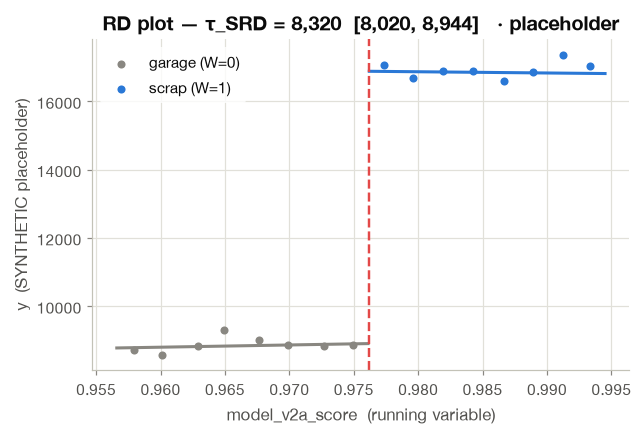

In [36]:
# Figure — the RD plot: binned outcome means either side of the cutoff + linear fits
def rd_binscatter(frame, c, outcome, ax, nbins=16, window=None):
    # Binned outcome means + local linear fit each side of c (house-style RD plot).
    x, y = frame["x"].values, frame[outcome].values
    h = window or (base["h"] * 1.5)
    m = np.abs(x - c) <= h
    x, y = x[m], y[m]
    for side, col, lab in [((x < c), figstyle.NEUTRAL, "garage (W=0)"),
                           ((x >= c), figstyle.PRIMARY, "scrap (W=1)")]:
        xs, ys = x[side], y[side]
        if len(xs) < 3:
            continue
        edges = np.linspace(xs.min(), xs.max(), nbins // 2 + 1)
        idx = np.digitize(xs, edges)
        bx = [xs[idx == k].mean() for k in range(1, len(edges)) if (idx == k).any()]
        by = [ys[idx == k].mean() for k in range(1, len(edges)) if (idx == k).any()]
        ax.scatter(bx, by, color=col, s=28, label=lab, zorder=3)
        if len(xs) > 1:
            coef = np.polyfit(xs, ys, 1)
            gx = np.linspace(xs.min(), xs.max(), 50)
            ax.plot(gx, np.polyval(coef, gx), color=col, lw=2)
    ax.axvline(c, color=figstyle.CAUTION, lw=1.6, ls="--")
    ax.set_xlabel(f"{RUNNING_VAR}  (running variable)")
    ax.set_ylabel(f"{outcome}" + ("  (SYNTHETIC placeholder)" if PLACEHOLDER else ""))
    ax.legend()

fig, ax = plt.subplots(figsize=figstyle.FIG_1)
rd_binscatter(frame, CUTOFF, "y", ax)
ttl = f"RD plot — τ_SRD = {base['tau_conv']:,.0f}  [{base['ci_lo']:,.0f}, {base['ci_hi']:,.0f}]"
ax.set_title(ttl + ("   · placeholder" if PLACEHOLDER else ""))
figstyle.save(fig, "04_01_rdd_phase2_rdplot"); plt.show()

## Interpretation & scope conditions  *(state these with any τ)*

- **τ_SRD is a boundary LATE** — the effect for cars *near* the cutoff, not the whole
  scrapped population. Deep-tail cars (score ≫ c) are **not identified**: no garage
  counterfactual exists there (positivity violation). Restrict causal claims to the
  mid-score overlap band — P7 §5.10 trimming language.
- **This is static marginal harm, not loop amplification.** RDD prices the scrap
  decision's one-shot effect on payout; it does *not* measure the year-over-year
  contamination feedback. That is the job of the DiD / oracle-gap detection leg.
- **£ translation:** τ_SRD × (marginal scraps in the overlap band) → the pound cost
  attributable to boundary scrapping. Triangulate across outcomes (payout, cycle
  time, salvage recovery) as they arrive — don't rest on payout alone.
- **Synthetic caveat.** The operational cutoff sits in the far right tail (τ_v ≈
  0.976), so the right-of-cutoff sample is thin here; effective-N is reported with every
  estimate. Real Allianz data will have more mass at the true cutoff.

### Plugging in the real outcome (one line)

1. Add a `payout` (or `total_cost`, `salvage_recovery`, …) column to the log.
2. Set `OUTCOME_COL = "payout"` in Phase 0 — the placeholder switch turns itself off.
3. Re-run. `estimate_effect` / `robustness_suite` / `rd_binscatter` run **unchanged**.
4. Re-point `gate_c_placebo`'s outcome at `payout` for a placebo on the real outcome.

*Suggested `src/effect_estimation/` split if this graduates out of the notebook:*
`assemble.py` (Phase 0) · `validity.py` (Phase 1, runs now) · `estimate.py`
(Phase 2) · `report.py` (figures). The notebook mirrors that ordering.